## ASL Classification using VGG-16 (Transfer Learning)

Use American Sign Language(ASL) dataset to get a better understanding of Transfer Learning using the VGG-16 model architecture. Since the dataset contains different hnd signals, which are not a part of the ImageNet dataset, it is expected that transfer learning will be less effective. 

In [1]:
import requests
import zipfile

import numpy as np
from dataclasses import dataclass

import tensorflow as tf
import keras
from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### Download the dataset

In [4]:
def downloadDataset(url, fileName):
    file = requests.get(url)

    open(fileName, "wb").write(file.content)


def unzipFile(zippedFileName=None):
    try:
        with zipfile.ZipFile(zippedFileName) as z:
            z.extractall("./")
            print("Extracted completely")
    except:
        print("Invalid file")

In [ ]:
downloadDataset(
    "https://www.dropbox.com/s/7huaqeavdbz32la/dataset_ASL_150.zip?dl=1",
    "dataset_ASL_150.zip",
)

unzipFile(zippedFileName="dataset_ASL_150.zip")

Extracted completely


### Dataset and Traning Config

In [2]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    CHANNELS: int = 3
    NUM_CLASSES: int = 29
    BATCH_SIZE: int = 32
    DATA_ROOT: str = "./dataset"


@dataclass(frozen=True)
class TrainingConfig:
    LEARNING_RATE: int = 0.0001
    EPOCHS: int = 51
    CHECKPOINT_FILEPATH: str = "./classification_asl_vgg16_transfer_learning.keras"

### VGG-16 Model

In [3]:
inputShape = (DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH, DatasetConfig.CHANNELS)

convBase = keras.applications.vgg16.VGG16(
    include_top=False, weights="imagenet", input_shape=inputShape
)
convBase.trainable = False
print(convBase.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [4]:
# Add the classification layer
inputs = keras.Input(shape=inputShape)

x = keras.applications.vgg16.preprocess_input(inputs)
x = convBase(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
outputs = keras.layers.Dense(DatasetConfig.NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 29)        │      7,453 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,144,925 (80.66 MB)

 Trainable params: 6,430,237 (24.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


### Prepare the datasets

In [5]:
trainDataset = image_dataset_from_directory(
    DatasetConfig.DATA_ROOT,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    image_size=inputShape[:2],
    seed=42,
    validation_split=0.2,
    subset="training",
)
validDataset = image_dataset_from_directory(
    DatasetConfig.DATA_ROOT,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    image_size=inputShape[:2],
    seed=42,
    validation_split=0.2,
    subset="validation",
)

Found 4350 files belonging to 29 classes.
Using 3480 files for training.
Found 4350 files belonging to 29 classes.
Using 870 files for validation.


### Display sample images

2025-11-30 08:58:15.977395: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


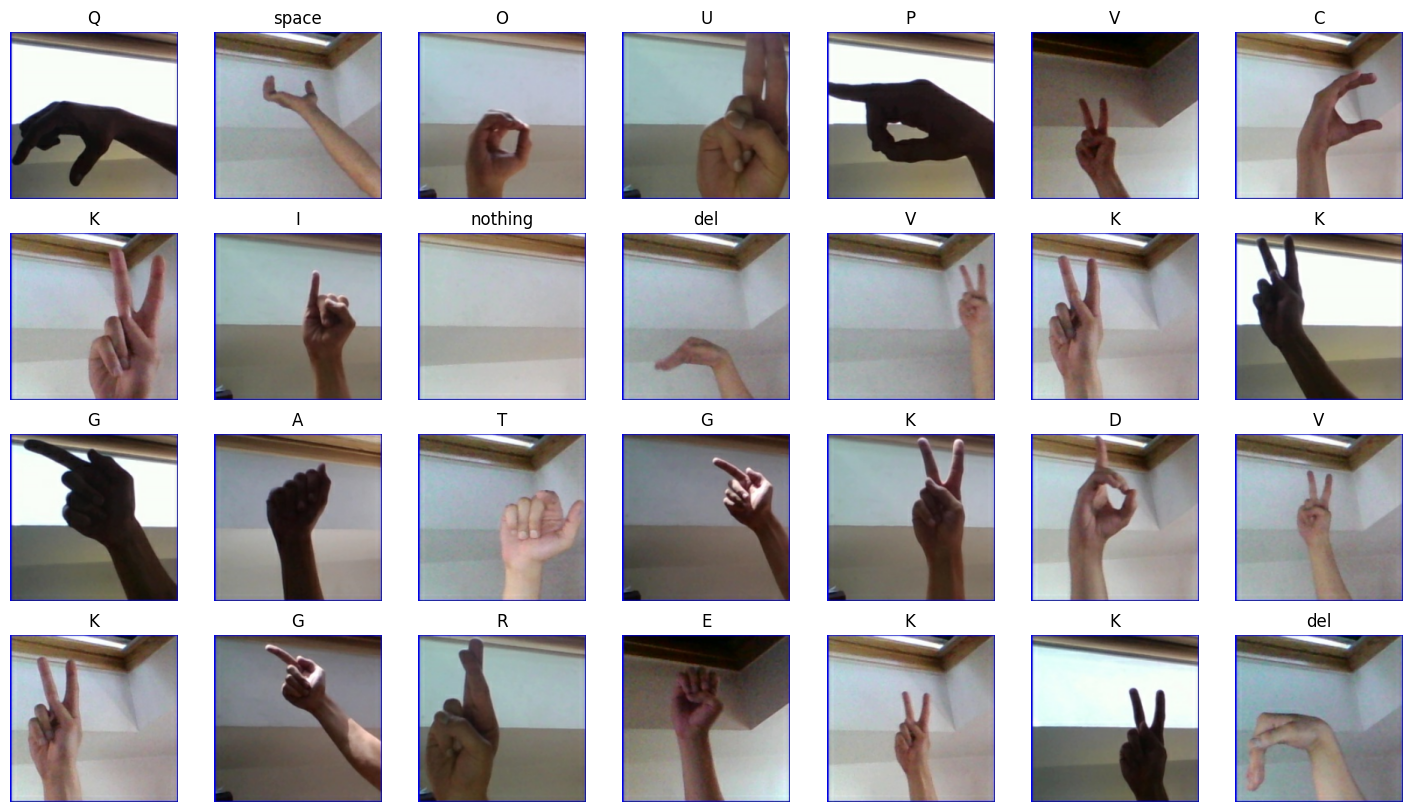

In [6]:
classNames = trainDataset.class_names

numRows = 4
numCols = 7

plt.figure(figsize=(18, 10))
for imagesBatch, labelsBatch in trainDataset.take(1):
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)
        plt.imshow(imagesBatch[i].numpy().astype("uint8"))

        truthIndex = np.nonzero(labelsBatch[i].numpy())
        plt.title(classNames[truthIndex[0][0]])
        plt.axis("off")

plt.show()
plt.close()

### Base Model Evaluation before final training

Compile and evaluate the model before the dense classifier is trained.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

In [8]:
print(
    f"Model accuracy before final training: {model.evaluate(validDataset)[1]*100:.3f}"
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.0276 - loss: 18.3751
Model accuracy before final training: 2.759


### Train the model

In [9]:
modelCheckpointCallback = keras.callbacks.ModelCheckpoint(
    TrainingConfig.CHECKPOINT_FILEPATH,
    save_best_only=True,
    save_weights_only=False,
    monitor="val_accuracy",
    mode="max",
)

trainingResults = model.fit(
    trainDataset,
    epochs=TrainingConfig.EPOCHS,
    callbacks=modelCheckpointCallback,
    validation_data=validDataset,
)

Epoch 1/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.4968 - loss: 3.2840 - val_accuracy: 0.7575 - val_loss: 0.9506
Epoch 2/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9236 - loss: 0.2434 - val_accuracy: 0.8701 - val_loss: 0.5035
Epoch 3/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9879 - loss: 0.0466 - val_accuracy: 0.8885 - val_loss: 0.4211
Epoch 4/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9977 - loss: 0.0122 - val_accuracy: 0.8989 - val_loss: 0.4035
Epoch 5/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.9997 - loss: 0.0053 - val_accuracy: 0.9080 - val_loss: 0.3689
Epoch 6/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9092 - val_loss: 0.3579
Epoch 7/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9115 - val_loss: 0.3545
Epoch 8/51
109/109 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 1.0000 - loss: 0.0014 - val_accu

### Plot the metrics

In [31]:
def plotMetrics(metrics, metricsName=None, yLabel=None, yLim=None, colours=None):
    if not (isinstance(metricsName, list) or isinstance(metricsName, tuple)):
        metricsName = [
            metricsName,
        ]
        metric = [
            metrics,
        ]
        colours = [
            colours,
        ]

    plt.figure(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        plt.plot(metric, color=colours[idx], label=metricsName[idx])

    # plt.xlabel(xlabel="Epoch")
    plt.xlim(0, TrainingConfig.EPOCHS - 1)
    # plt.ylabel(ylabel=yLabel)
    plt.ylim(yLim)
    plt.title(yLabel)
    plt.grid(True)

    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.show(block=False)
    plt.close()

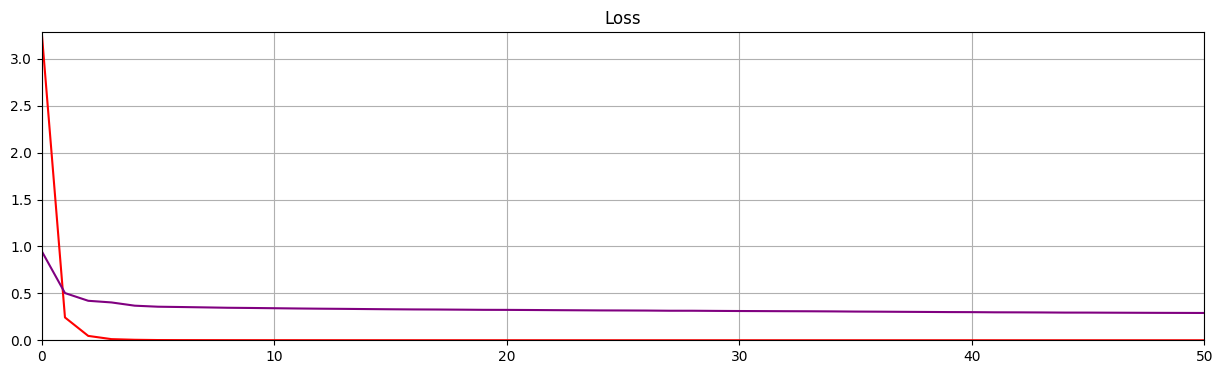

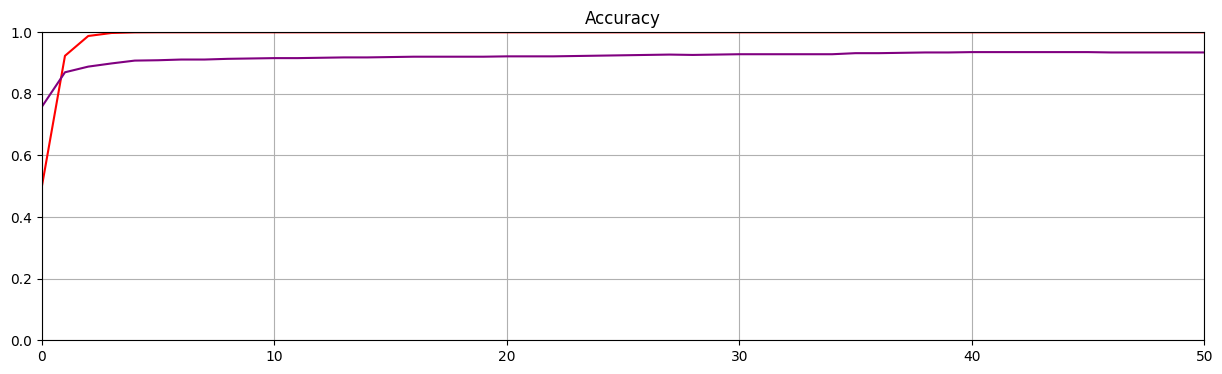

In [32]:
loss = trainingResults.history["loss"]
val_loss = trainingResults.history["val_loss"]
accuracy = trainingResults.history["accuracy"]
val_accuracy = trainingResults.history["val_accuracy"]

plotMetrics(
    [loss, val_loss],
    ["Training Loss", "Validation Loss"],
    yLabel="Loss",
    yLim=(0, max(max(loss), max(val_loss))),
    colours=["red", "purple"],
)
plotMetrics(
    [accuracy, val_accuracy],
    ["Training Accuracy", "Validation Accuracy"],
    yLabel="Accuracy",
    yLim=(0, 1.0),
    colours=["red", "purple"],
)

### Model Evaluation

In [33]:
savedModel = keras.models.load_model(TrainingConfig.CHECKPOINT_FILEPATH)

print(f"Saved best model accuracy: {savedModel.evaluate(validDataset)[1]*100:.3f}%")

28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9356 - loss: 0.3000
Saved best model accuracy: 93.563%


In [34]:
def displayWrongPredictions(model, dataset):
    numRows = 4
    numCols = 8
    wrongPredictionsCount = 0

    plt.figure(figsize=(20, 15))
    for imagesBatch, labelsBatch in dataset:
        predictions = model.predict(imagesBatch)
        for idx, label in enumerate(labelsBatch):
            truthIndex = np.nonzero(label.numpy())
            predictionIndex = tf.argmax(predictions[idx]).numpy()

            if truthIndex == predictionIndex:
                continue

            wrongPredictionsCount += 1

            if wrongPredictionsCount > numRows * numCols:
                break

            ax = plt.subplot(numRows, numCols, wrongPredictionsCount)
            title = (
                str(classNames[predictionIndex])
                + " : "
                + str(classNames[truthIndex[0][0]])
            )
            titleObj = plt.title(title)

            plt.setp(titleObj, color="red")
            plt.axis("off")
            plt.imshow(imagesBatch[idx].numpy().astype("uint8"))
    # return

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-11-30 13:29:09.637924: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


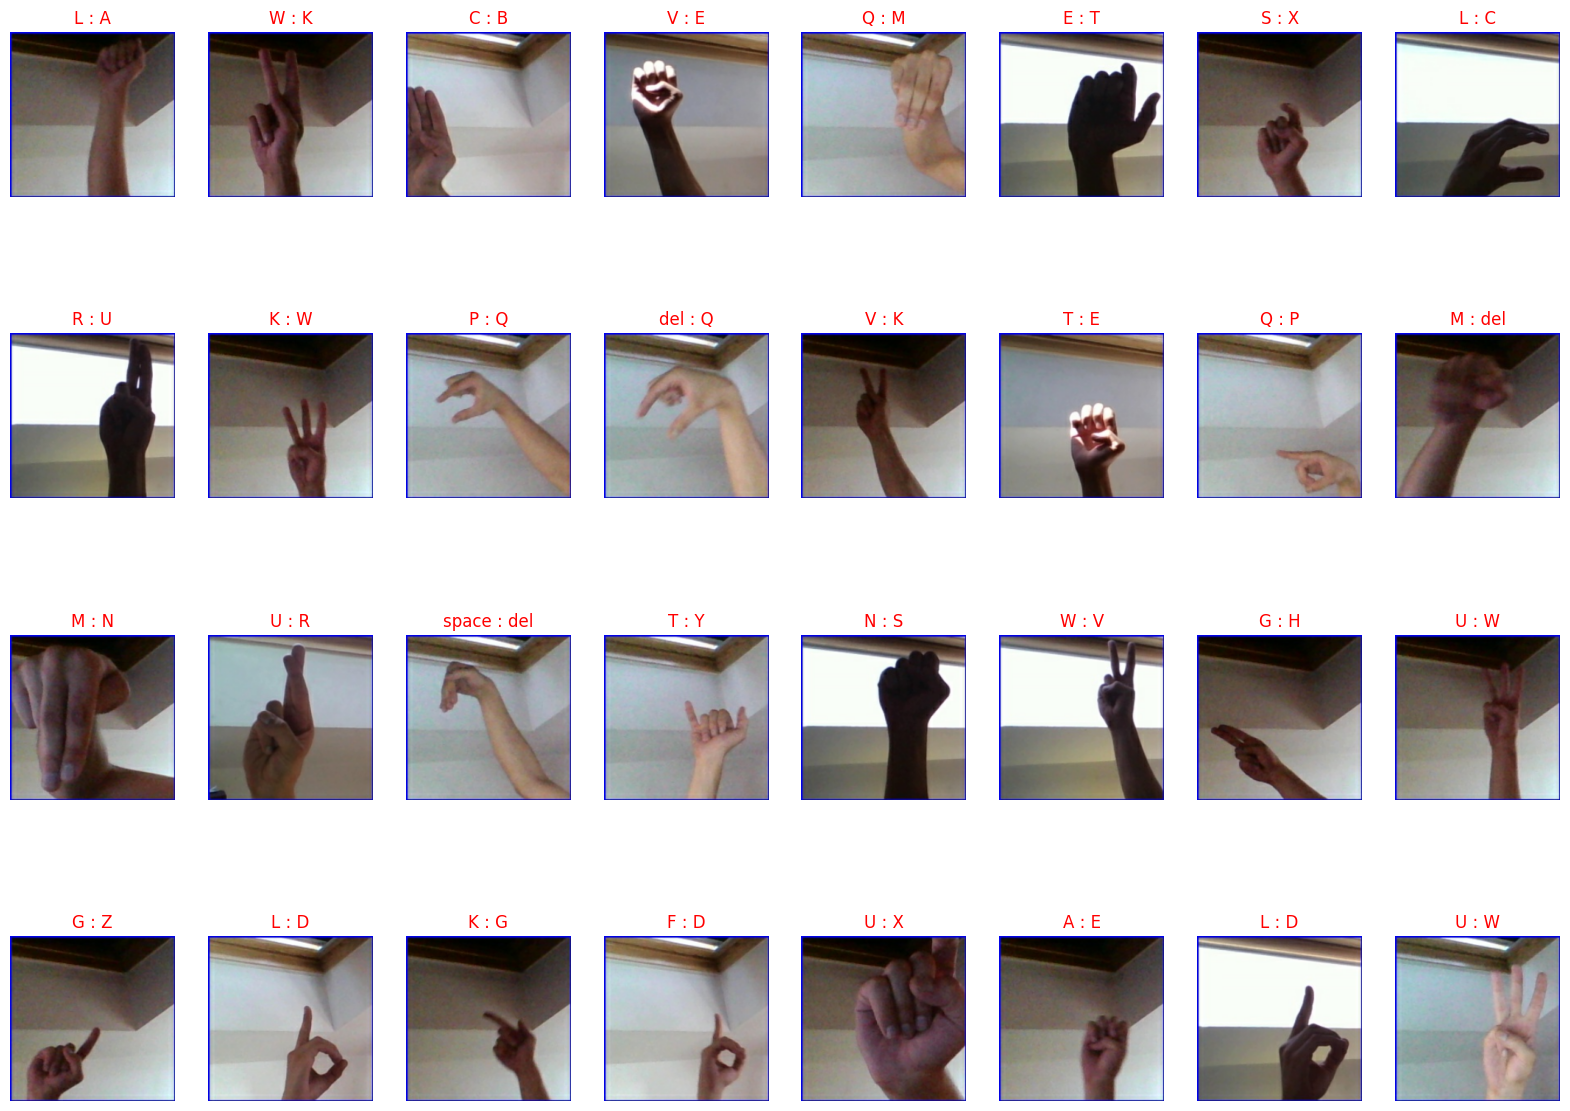

In [35]:
displayWrongPredictions(savedModel, validDataset)